<h1 style="color: #CEDDF4;">DEPI Round 4, MS Data Engineer and AI Track</h1>
<h2 style="color: #CEDDF4;" >Final Project: Gold and Oil Prediction System</h2>
<h3 style="color: #CEDDF4;" > Part (2): Python Code for Machine Learning and Modeling</h3>

<h4 style="color: #CEDDF4;" >1. Import Libraries</h4>

In [68]:
import os
import math
from pathlib import Path
from functools import reduce

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor

import lightgbm as lgb

import joblib

In [69]:
base_dir = Path.cwd()
#raw data path to contain all raw files gathered either manually, web scraping or APIs
raw_data_dir=base_dir/'raw data'
#cleaned data path, will be separated into two main folders which are: market data (contains the data with daily logs) and macroeconomic data
##cleaned market data
cleaned_market_data_dir=base_dir/'cleaned data'/'market_data'
##cleaned macroeconomic data
cleaned_macro_data_dir=base_dir/'cleaned data'/'macroeconomic_data'
##ai modeling data
ai_data_dir=base_dir/'ai model'

<h4 style="color: #CEDDF4;" >1. Data Loading and Processing</h4>

In [70]:
def make_tag(filename):
    tag = filename
    tag = tag.replace('global_', '').replace('usa_', '').replace('egy_', '')
    tag = tag.replace('_prices', '').replace('_price', '').replace('_index', '').replace('_rate', '')
    return tag

In [71]:
#the below function is made to call all the date within specific folder (market / macro) and make final cleaning and sorting methods on it to be using in our master table
def loading(filename, tag, dir):
    df = pd.read_csv(dir / f"{filename}.csv")
    df = df.drop(columns=['id', 'region', 'ticker'], errors='ignore')
    df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed', errors='coerce')
    df = df.rename(columns={c: f"{tag}_{c}" for c in df.columns if c != 'date'})
    df = df.drop_duplicates(subset='date')
    df = df.set_index('date')
    full_dates = pd.date_range(start='2016-01-01', end='2026-03-29', freq='D')
    df = df.reindex(full_dates)
    first_valid = df.first_valid_index()
    if first_valid is not None:
        df.loc[:first_valid] = df.loc[:first_valid].bfill()
    df = df.ffill()
    df = df.reset_index().rename(columns={'index': 'date'})
    return df

In [72]:
#the below is for loop to iterate over all files within cleaned market data 
all_market_df=[]
for filepath in cleaned_market_data_dir.glob("*.csv"):
    raw_file_name = filepath.stem
    tag = make_tag(raw_file_name)
    new_df = loading(raw_file_name, tag, cleaned_market_data_dir)
    all_market_df.append(new_df)

In [73]:
#the below is a minor tweak to egy_cpi file in macroeconomic data folder which is obtained via data_cleaning.ipynb section 2.1
egy_cpi=pd.read_csv(cleaned_macro_data_dir/'egy_cpi.csv')
egy_cpi=egy_cpi.rename(columns={'year':'date'})
egy_cpi.to_csv(cleaned_macro_data_dir/'egy_cpi.csv',index=False)

In [74]:
#the below is for loop to iterate over all files within cleaned macroeconomic data data 
all_macro_df=[]
for filepath in cleaned_macro_data_dir.glob("*.csv"):
    raw_file_name = filepath.stem
    tag = make_tag(raw_file_name)
    new_df = loading(raw_file_name, tag, cleaned_macro_data_dir)
    all_macro_df.append(new_df)

In [75]:
#get all dataframes from previous steps in one dataframe as reduce function takes only one argument
all_df = all_macro_df + all_market_df
#create the master table and make data column the primary key for merging process
master_table = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), all_df)
master_table = master_table.dropna(axis=1, how='all')

In [76]:
#saving the master table into a csv file to be used in the modeling
master_table.to_csv(ai_data_dir/'master_table.csv',index=False)

In [77]:
df=pd.read_csv(ai_data_dir/'master_table.csv')

In [78]:
df = df.bfill().ffill()

In [79]:
df.to_csv(ai_data_dir/'new_master_table.csv',index=False)

In [80]:
#only when VS Code crashes
df=pd.read_csv(ai_data_dir/'new_master_table.csv')

In [81]:
df.shape

(3741, 184)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3741 entries, 0 to 3740
Columns: 184 entries, date to sp500_open_usd
dtypes: float64(175), int64(1), object(8)
memory usage: 5.3+ MB


In [83]:
df.head()

,date,china_cpi_value,china_energy_oil_elec_pct,china_energy_energy_use,china_energy_fuel_imports,china_energy_fuel_exports,china_energy_gas_elec_pct,china_gdp_value_usd,china_ir_value,egypt_energy_oil_elec_pct,...,dowjones_low_usd,dowjones_open_usd,nasdaq_price_usd,nasdaq_high_usd,nasdaq_low_usd,nasdaq_open_usd,sp500_price_usd,sp500_high_usd,sp500_low_usd,sp500_open_usd
0,2016-01-01,101.1,0.167214,2149.20475,12.091734,1.281001,2.749878,1.624100e+13,2.9,15.533161,...,16957.630859,17405.480469,4903.089844,4903.089844,4846.979980,4897.649902,2012.660034,2038.199951,1989.680054,2038.199951
1,2016-01-02,101.1,0.167214,2149.20475,12.091734,1.281001,2.749878,1.624100e+13,2.9,15.533161,...,16957.630859,17405.480469,4903.089844,4903.089844,4846.979980,4897.649902,2012.660034,2038.199951,1989.680054,2038.199951
2,2016-01-03,101.1,0.167214,2149.20475,12.091734,1.281001,2.749878,1.624100e+13,2.9,15.533161,...,16957.630859,17405.480469,4903.089844,4903.089844,4846.979980,4897.649902,2012.660034,2038.199951,1989.680054,2038.199951
3,2016-01-04,101.1,0.167214,2149.20475,12.091734,1.281001,2.749878,1.624100e+13,2.9,15.533161,...,16957.630859,17405.480469,4903.089844,4903.089844,4846.979980,4897.649902,2012.660034,2038.199951,1989.680054,2038.199951
4,2016-01-05,101.1,0.167214,2149.20475,12.091734,1.281001,2.749878,1.624100e+13,2.9,15.533161,...,17038.609375,17147.500000,4891.430176,4926.729980,4872.740234,4917.839844,2016.709961,2021.939941,2004.170044,2013.780029


In [84]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed', errors='coerce')
data = df[df['date'] <= '2025-08-30']
data_clean = data.copy()

for col in data_clean.columns:
    if data_clean[col].dtype == "object":
        data_clean[col] = data_clean[col].astype(str).str.replace('%', '', regex=False)
        data_clean[col] = pd.to_numeric(data_clean[col], errors='ignore')
data_clean = data_clean.apply(pd.to_numeric, errors='coerce')
data_clean = data_clean.dropna(axis=1, how='all')


C:\Users\Basio_Wolf\AppData\Local\Temp\ipykernel_12860\1030851805.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data_clean[col] = pd.to_numeric(data_clean[col], errors='ignore')
C:\Users\Basio_Wolf\AppData\Local\Temp\ipykernel_12860\1030851805.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data_clean[col] = pd.to_numeric(data_clean[col], errors='ignore')
C:\Users\Basio_Wolf\AppData\Local\Temp\ipykernel_12860\1030851805.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data_clean[col] = pd.to_numeric(data_clean[col], errors='ignore')
C:\Users\Basio_Wolf\AppData\Local\Temp\ipykernel_12860\1030851805.py:8: FutureWarning: errors='ig

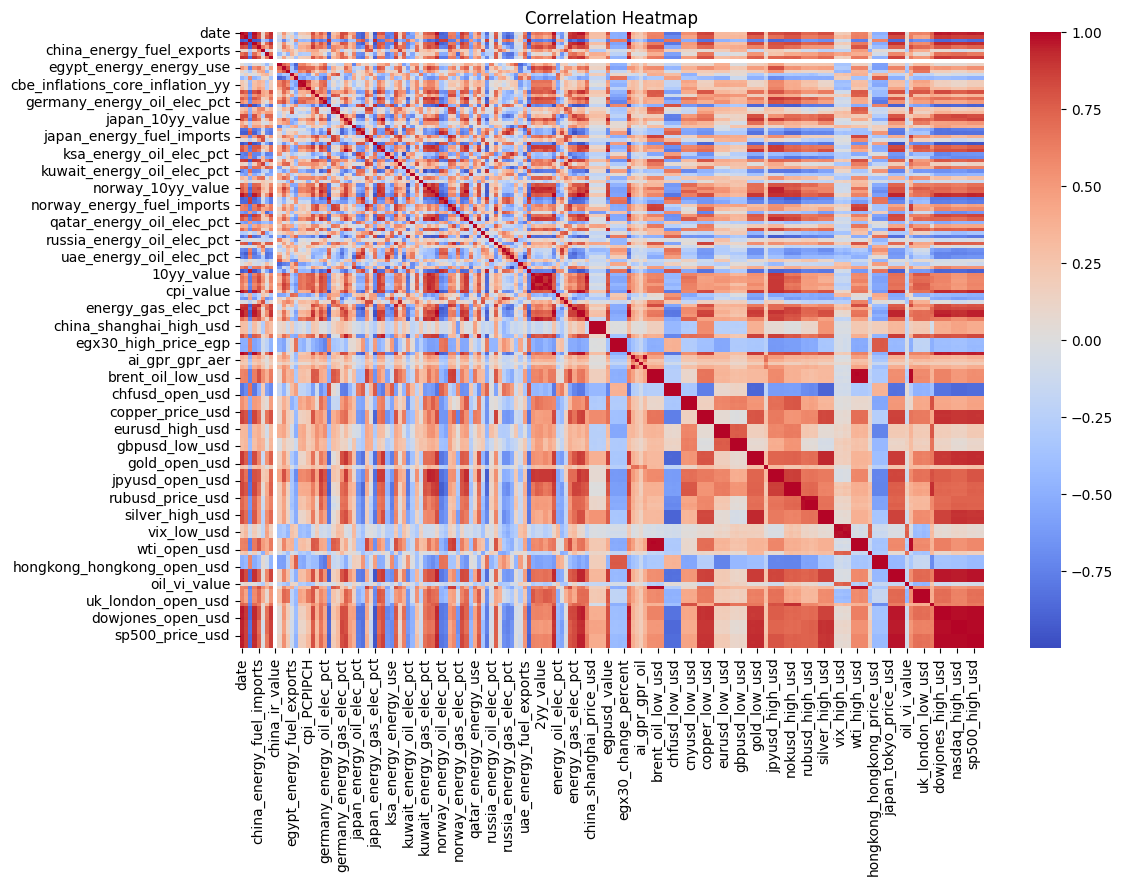

In [85]:
corr = data_clean.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

# Phase 1: Setup

In [86]:

### define target variable
target_col = 'gold_price_usd'
### avoid modifying original dataset
df = df.copy()  

# Phase 2: Time preprocessing

In [87]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed', errors='coerce') 

df = df.sort_values('date')  

# Phase 3: Remove leakage features

In [88]:
leakage_keywords = [
    '_open_', '_high_', '_low_',
    'gpr_event',
    'ai_gpr_Unnamed',
    'gold_price_oz_egp',
    'cbe_inflations_headline_inflation_yy',
    'cbe_inflations_core_inflation_yy'
]
### remove features that leak future info
df = df.drop(columns=[
    c for c in df.columns
    if any(k in c for k in leakage_keywords)
], errors='ignore')  


# Phase 4: Macro feature engineering


In [89]:
df['real_rate_us'] = df['usd_fedfunds_value'] - df['cpi_value']  # US real interest rate
df['real_rate_eu'] = df['euro_interest_value'] - df['euro_inflation_value']  # EU real interest rate

df['oil_x_dxy'] = df['brent_oil_price_usd'] * df['dollarindex_value']  # oil-dollar interaction
df['vix_x_dxy'] = df['vix_price_usd'] * df['dollarindex_value']  # volatility-dollar interaction

df['sp500_mom'] = df['sp500_price_usd'].pct_change()  # market momentum

# Phase 5: Target engineering


In [90]:
df['log_price'] = np.log(df[target_col])  # log transformation for stability
df['return'] = df['log_price'].diff()  # compute returns

df['target'] = df['return'].rolling(5).mean().shift(-1)  # future smoothed return target
df['target'] = df['target'].clip(-0.03, 0.03)  # limit extreme values



# Phase 6: Lag features

In [91]:
for lag in [1,2,3,5,10,20]:
    df[f'return_lag_{lag}'] = df['return'].shift(lag)  # past returns

df['log_price_lag1'] = df['log_price'].shift(1)  # previous price level

# Phase 7: Volatility and momentum


In [92]:
df['vol_7'] = df['return'].rolling(7).std().shift(1)  # short volatility
df['vol_20'] = df['return'].rolling(20).std().shift(1)  # long volatility
df['mom_7'] = df['return'].rolling(7).mean().shift(1)  # short momentum

df['price_trend_7'] = df[target_col].rolling(7).mean().shift(1)  # trend feature

# Phase 8: Data cleaning


In [93]:
df = df.dropna()  # remove missing values

# Phase 9: Feature selection


In [94]:
features = [c for c in df.columns if c not in ['date', target_col, 'target']]  # model inputs

# Phase 10: Train-test split


In [95]:
train = df[df['date'] <= '2025-12-30']  # training period
test = df[(df['date'] > '2025-12-30')]  # testing period

X_train = train[features]
y_train = train['target']

X_test = test[features]
y_test = test['target']

# Phase 11: Time Series Cross Validation


In [96]:
tscv = TimeSeriesSplit(n_splits=5)

for i, (tr, val) in enumerate(tscv.split(X_train)):

    model_cv = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        num_leaves=64,
        max_depth=6
    )

    model_cv.fit(X_train.iloc[tr], y_train.iloc[tr])  # train fold model

    pred = model_cv.predict(X_train.iloc[val])  # validation prediction

    print("Fold", i+1)
    print("MAE:", mean_absolute_error(y_train.iloc[val], pred))  # error
    print("DIR:", np.mean(np.sign(y_train.iloc[val]) == np.sign(pred)))  # direction accuracy


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001938 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9199
[LightGBM] [Info] Number of data points in the train set: 606, number of used features: 128
[LightGBM] [Info] Start training from score 0.000299
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

# Phase 12: Full model training


In [97]:
model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15043
[LightGBM] [Info] Number of data points in the train set: 3631, number of used features: 129
[LightGBM] [Info] Start training from score 0.000383


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.01
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# Phase 13: Feature selection (importance-based)


In [98]:
selector = SelectFromModel(model, threshold='median', prefit=True)

X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

model.fit(X_train_sel, y_train)

C:\Users\Basio_Wolf\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\Basio_Wolf\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001309 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14023
[LightGBM] [Info] Number of data points in the train set: 3631, number of used features: 65
[LightGBM] [Info] Start training from score 0.000383


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.01
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# Phase 14: Prediction (full model)


In [99]:
pred_returns = model.predict(X_test_sel)

C:\Users\Basio_Wolf\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


# Phase 15: Price reconstruction (full model)


In [100]:
start_price = train[target_col].iloc[-1]

prices = [start_price]

for r in pred_returns:
    prices.append(prices[-1] * np.exp(r))

prices = prices[1:]

test = test.copy()
test['pred_price'] = prices

# Phase 16: Evaluation (full model)


In [101]:
mae = mean_absolute_error(test[target_col], test['pred_price'])
direction = np.mean(np.sign(test['target']) == np.sign(pred_returns))

print("Full Model MAE:", mae)
print("Full Model Direction:", direction)


Full Model MAE: 383.6106657289392
Full Model Direction: 0.7386363636363636


# Phase 17: Top Features Extraction


In [102]:
importance_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

importance_model.fit(X_train, y_train)

importance = pd.Series(
    importance_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002340 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15043
[LightGBM] [Info] Number of data points in the train set: 3631, number of used features: 129
[LightGBM] [Info] Start training from score 0.000383


# Phase 18: Top features selection


In [103]:
top_k = 15
top_features = importance.head(top_k).index.tolist()

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# Phase 19: Train top features model


In [104]:
top_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

top_model.fit(X_train_top, y_train)

pred_top = top_model.predict(X_test_top)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000375 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 3631, number of used features: 15
[LightGBM] [Info] Start training from score 0.000383


# Phase 20: Price reconstruction (top model)


In [105]:
prices_top = [start_price]

for r in pred_top:
    prices_top.append(prices_top[-1] * np.exp(r))

prices_top = prices_top[1:]

test['pred_price_top'] = prices_top

# Phase 21: Evaluation (top model)


In [106]:
mae_top = mean_absolute_error(test[target_col], test['pred_price_top'])
direction_top = np.mean(np.sign(test['target']) == np.sign(pred_top))

print("Top Features Model MAE:", mae_top)
print("Top Features Model Direction:", direction_top)

Top Features Model MAE: 112.75224422545278
Top Features Model Direction: 0.7840909090909091


# Phase 22: Visualization comparison


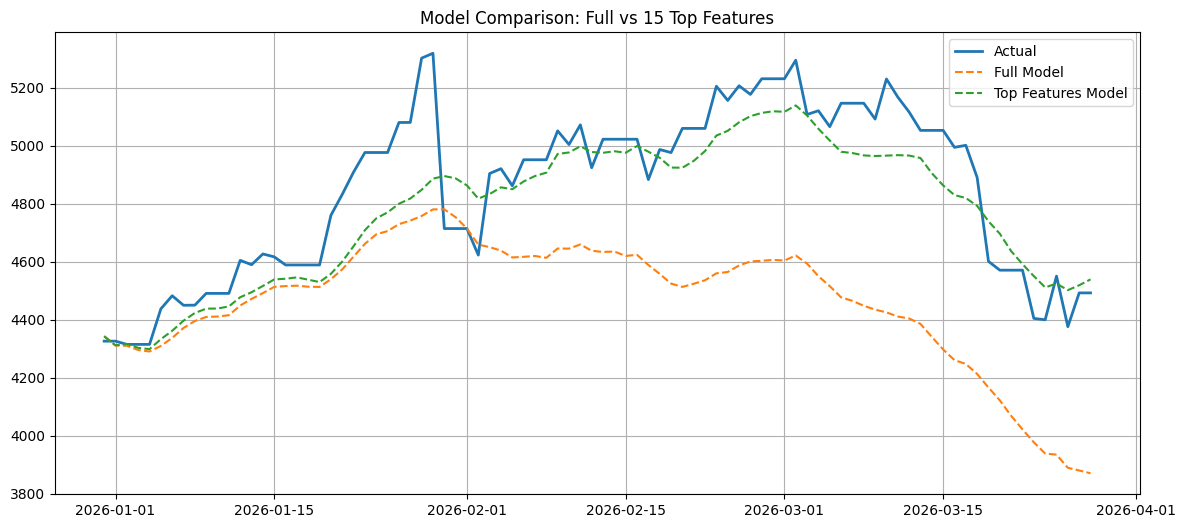

In [107]:
plt.figure(figsize=(14,6))

plt.plot(test['date'], test[target_col], label='Actual', linewidth=2)
plt.plot(test['date'], test['pred_price'], label='Full Model', linestyle='--')
plt.plot(test['date'], test['pred_price_top'], label='Top Features Model', linestyle='--')

plt.legend()
plt.title("Model Comparison: Full vs 15 Top Features")
plt.grid()
plt.show()